In [1]:
import pandas as pd
import numpy as np
import sklearn as skl
import matplotlib.pyplot as plt 
import seaborn as sns
import semopy
import pgmpy

In [2]:
pd.set_option("display.max_columns", None)
# pd.set_option("display.max_rows", None)

In [3]:
pd.set_option("display.float_format", "{:.0f}".format)

# Data ETL

In [4]:
full_responses = pd.read_csv('../data/survey/survey_responses.csv', low_memory=False)

In [5]:
full_responses.head()

,response_id,metadata_authenticated,metadata_booking_channel,metadata_booking_channel_code,metadata_booking_date,metadata_class_of_service,metadata_class_of_service_code,metadata_coach_number,metadata_compensation_flag,metadata_currency,metadata_delay_code,metadata_delay_at_arrival,metadata_departure_date,metadata_departure_hour,metadata_destination_station,metadata_destination_station_code,metadata_device,metadata_device_code,metadata_disrup,metadata_origin_station,metadata_origin_station_code,metadata_point_of_sales,metadata_price,metadata_lounge_improvement_other_please_specify,metadata_station_verbatim,metadata_on_board_the_train_v,metadata_arrival_verbatim,metadata_staff_verbatim,metadata_overall_experience_v,metadata_reasons_for_choosing_other_please_specify,metadata_q14_op,metadata_q17_op,metadata_residence_another_country_please_select,metadata_recommendation_nps_a,metadata_assistance_service_v,metadata_leisure_reason_other_please_specify,metadata_q_ambiguous_text_present,metadata_q_ambiguous_text_questions,metadata_q_lang,metadata_q_recaptcha_error,metadata_q_recaptcha_score,metadata_q_recaptcha_status,metadata_q_straightlining_count,metadata_q_straightlining_percentage,metadata_q_straightlining_questions,metadata_q_total_duration,metadata_q_url,metadata_q_unanswered_percentage,metadata_q_unanswered_questions,metadata_recommendation_nps,metadata_route,metadata_route_code,metadata_seat_number,metadata_segment,metadata_segment_code,metadata_selected_language,metadata_tariff_code,metadata_tier_level,metadata_tier_level_code,metadata_train_number,metadata_train_type,metadata_train_type_code,metadata_trips_l12_months,metadata_user_agent,metadata_record_id,metadata_distribution_channel,metadata_duration,metadata_end_date,metadata_progress,metadata_recorded_date,metadata_start_date,metadata_user_language,question_overall_satisfaction_booking_experience,question_overall_satisfaction_wifi_onboard_the_train,question_overall_satisfaction_experience_at_departure_station,question_overall_satisfaction_journey_punctuality,question_overall_satisfaction_comfort_onboard_the_train,question_overall_satisfaction_cleanliness_onboard_the_train,question_overall_satisfaction_overall_service_from_eurostar_staff,question_overall_satisfaction_information_provided_to_you_before_travelling,question_lounge_overall_f_b_your_overall_experience_in_the_premier_lounge,question_lounge_overall_f_b_the_beverage_offering_in_the_lounge,question_lounge_overall_f_b_available_space_seating,question_lounge_overall_f_b_lounge_staff,question_lounge_overall_f_b_cocktail_bar,question_lounge_overall_f_b_newspapers_magazines,question_lounge_overall_f_b_your_welcome_arrival_at_the_lounge,question_lounge_overall_f_b_atmosphere_ambience_in_the_lounge,question_lounge_overall_f_b_furniture_and_d_cor_in_the_lounge,question_lounge_overall_f_b_information_regarding_your_train_departure,question_lounge_overall_f_b_cleanliness_of_the_lounge,question_lounge_overall_f_b_the_food_offering_in_the_lounge,question_lounge_improvement,question_onboard_catering_met_quality_of_food_in_meal_service,question_onboard_catering_met_receiving_preferred_meal_option,question_onboard_catering_met_quality_of_beverages_in_meal_service,question_onboard_catering_met_staff_hospitality_during_meal_service,question_onboard_catering_met_portion_sizes,question_onboard_catering_met_range_of_food_available_in_meal_service,question_onboard_catering_met_range_of_drinks_available_in_meal_service,question_onboard_catering_met_presentation_of_food,question_disruption_performan_the_information_available_to_you,question_disruption_performan_the_compensation_you_received_as_a_result_of_this_disruption,question_disruption_performan_frequency_regularity_of_updates,question_disruption_performan_the_accuracy_of_all_information_provided,question_disruption_performan_the_consistency_of_information_from_different_sources,question_disruption_performan_the_frequency_with_which_you_were_kept_updated,question_disruption_perfo

## Data quality check

In [6]:
df_raw = full_responses.copy()

missing_percentage = []

for col in full_responses.columns:
    missing_percentage.append({
        "variable": col,
        "NaN values": full_responses[col].isna().sum(),
        "NaN percentage": full_responses[col].isna().sum() / len(full_responses)
    })

missing_percentage = pd.DataFrame(missing_percentage)
missing_percentage = missing_percentage.sort_values(by= ["NaN percentage"], ascending=False)
# missing_percentage.to_csv("survey_responses_missing_profiles.csv", index=False)

### Straight-lining & unanswered questions

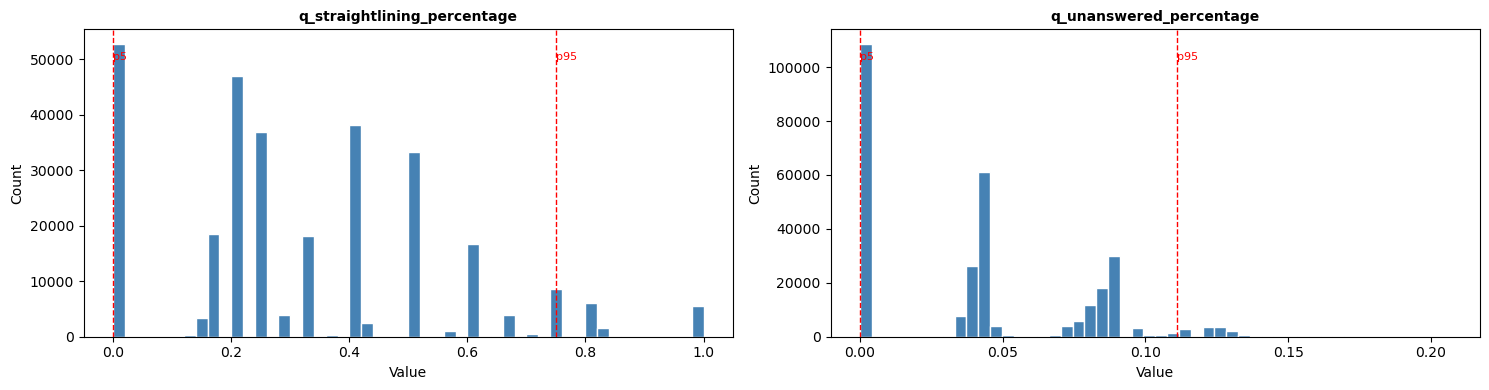

       metadata_q_straightlining_percentage  metadata_q_unanswered_percentage
count                                299005                            299005
mean                                      0                                 0
std                                       0                                 0
min                                       0                                 0
1%                                        0                                 0
5%                                        0                                 0
25%                                       0                                 0
50%                                       0                                 0
75%                                       0                                 0
95%                                       1                                 0
99%                                       1                                 0
max                                       1                     

In [7]:
cols_to_inspect = [
    "metadata_q_straightlining_percentage",
    "metadata_q_unanswered_percentage"
]

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

for ax, col in zip(axes, cols_to_inspect):
    data = full_responses[col].dropna()
    
    ax.hist(data, bins=50, color="steelblue", edgecolor="white")
    ax.set_title(col.replace("metadata_", ""), fontsize=10, fontweight="bold")
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")
    
    # Annotate with key percentiles
    for pct, val in [(5, data.quantile(0.05)), (95, data.quantile(0.95))]:
        ax.axvline(val, color="red", linestyle="--", linewidth=1)
        ax.text(val, ax.get_ylim()[1] * 0.9, f"p{pct}", color="red", fontsize=8)

plt.tight_layout()
plt.show()

# Print summary stats
print(full_responses[cols_to_inspect].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]))

In [8]:
straightline_bins = pd.cut(
    df_raw["metadata_q_straightlining_percentage"],
    bins=[0, 0.25, 0.5, 0.75, 1.0],
    labels=["0-25%", "25-50%", "50-75%", "75-100%"],
    include_lowest=True
)

cross_check_straightlining = df_raw.groupby(straightline_bins, observed=True).agg(
    n=("response_id", "count"),
    median_duration=("metadata_q_total_duration", "median"),
    mean_nps=("metadata_recommendation_nps_a", "mean"),
    mean_unanswered=("metadata_q_unanswered_percentage", "mean")
).round(3)

print(cross_check_straightlining)

                                           n  median_duration  mean_nps  \
metadata_q_straightlining_percentage                                      
0-25%                                 158793              396         8   
25-50%                                 96165              381         8   
50-75%                                 30695              348         9   
75-100%                                13352              315         9   

                                      mean_unanswered  
metadata_q_straightlining_percentage                   
0-25%                                               0  
25-50%                                              0  
50-75%                                              0  
75-100%                                             0  


In [9]:
df_raw["flag_high_straightliner"] = (
    df_raw["metadata_q_straightlining_percentage"] > 0.75
)

print(f"Flagged: {df_raw['flag_high_straightliner'].sum():,} ({df_raw['flag_high_straightliner'].mean():.1%})")

Flagged: 13,352 (4.5%)


In [10]:
unanswered_bins = pd.cut(
    df_raw["metadata_q_unanswered_percentage"],
    bins=[0, 0.05, 0.10, 0.15, 0.21],
    labels=["0-5%", "5-10%", "10-15%", "15-21%"],
    include_lowest=True
)

cross_check_unanswered = df_raw.groupby(unanswered_bins, observed=True).agg(
    n=("response_id", "count"),
    median_duration=("metadata_q_total_duration", "median"),
    mean_nps=("metadata_recommendation_nps_a", "mean"),
    mean_straightlining=("metadata_q_straightlining_percentage", "mean")
).round(3)

print(cross_check_unanswered)

                                       n  median_duration  mean_nps  \
metadata_q_unanswered_percentage                                      
0-5%                              208722              421         8   
5-10%                              74080              306         8   
10-15%                             15437              314         8   
15-21%                               766              319         7   

                                  mean_straightlining  
metadata_q_unanswered_percentage                       
0-5%                                                0  
5-10%                                               0  
10-15%                                              0  
15-21%                                              0  


In [11]:
df_raw["flag_high_unanswered"] = (
    df_raw["metadata_q_unanswered_percentage"] >= 0.15
)

print(f"High unanswered flagged: {df_raw['flag_high_unanswered'].sum():,} ({df_raw['flag_high_unanswered'].mean():.1%})")

High unanswered flagged: 845 (0.3%)


### Duration

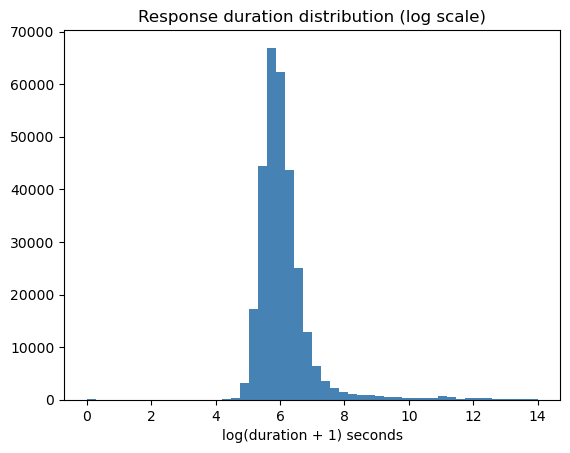

count    299005
mean       2787
std       29120
min           0
1%          147
5%          191
25%         280
50%         382
75%         560
95%        1558
99%       50269
max     1197021
Name: metadata_q_total_duration, dtype: float64


In [12]:
df_raw["metadata_q_total_duration"].dropna().apply(np.log1p).hist(bins=50, color="steelblue", grid=False)
plt.xlabel("log(duration + 1) seconds")
plt.title("Response duration distribution (log scale)")
plt.show()

print(df_raw['metadata_q_total_duration'].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]))

In [13]:
duration_thresholds = [0, 60, 120, 180, 240, 300, 360, 420, 480]

records = []
for threshold in duration_thresholds:
    subset = df_raw[df_raw["metadata_q_total_duration"] >= threshold]
    records.append({
        "threshold_s"  : threshold,
        "n_retained"   : len(subset),
        "pct_retained" : len(subset) / len(df_raw),
        "mean_nps"     : subset["metadata_recommendation_nps_a"].mean(),
        "median_nps"   : subset["metadata_recommendation_nps_a"].median(),
    })

pd.set_option("display.float_format", "{:.3f}".format)
print(pd.DataFrame(records).to_string(index=False))

 threshold_s  n_retained  pct_retained  mean_nps  median_nps
           0      299005         1.000     8.072       9.000
          60      298735         0.999     8.072       9.000
         120      298170         0.997     8.072       9.000
         180      288325         0.964     8.058       9.000
         240      255003         0.853     8.010       9.000
         300      208900         0.699     7.942       8.000
         360      164350         0.550     7.863       8.000
         420      128420         0.429     7.794       8.000
         480      100806         0.337     7.728       8.000


In [14]:
MIN_DURATION = 120
MAX_DURATION = 3600  # 1 hour

df_raw["flag_speeder"] = df_raw["metadata_q_total_duration"] < MIN_DURATION
df_raw["flag_tab_open"] = df_raw["metadata_q_total_duration"] > MAX_DURATION

print(f"Speeders flagged  : {df_raw['flag_speeder'].sum():,} ({df_raw['flag_speeder'].mean():.1%})")
print(f"Tab-open flagged  : {df_raw['flag_tab_open'].sum():,} ({df_raw['flag_tab_open'].mean():.1%})")

Speeders flagged  : 835 (0.3%)
Tab-open flagged  : 8,386 (2.8%)


### Summary

In [15]:
# ── Summary of all quality flags ─────────────────────────────────────────────
print("Quality flags summary:")
print(f"  Speeders (<120s)        : {df_raw['flag_speeder'].sum():,} ({df_raw['flag_speeder'].mean():.1%})")
print(f"  Tab-open (>3600s)       : {df_raw['flag_tab_open'].sum():,} ({df_raw['flag_tab_open'].mean():.1%})")
print(f"  High straightliner      : {df_raw['flag_high_straightliner'].sum():,} ({df_raw['flag_high_straightliner'].mean():.1%})")
print(f"  High unanswered         : {df_raw['flag_high_unanswered'].sum():,} ({df_raw['flag_high_unanswered'].mean():.1%})")

# How many rows flagged on ANY criterion
any_flag = (
    df_raw["flag_speeder"] |
    df_raw["flag_tab_open"] |
    df_raw["flag_high_straightliner"] |
    df_raw['flag_high_unanswered']
)
print(f"\n  Flagged on any criterion: {any_flag.sum():,} ({any_flag.mean():.1%})")
print(f"  Clean responses         : {(~any_flag).sum():,} ({(~any_flag).mean():.1%})")

Quality flags summary:
  Speeders (<120s)        : 835 (0.3%)
  Tab-open (>3600s)       : 8,386 (2.8%)
  High straightliner      : 13,352 (4.5%)
  High unanswered         : 845 (0.3%)

  Flagged on any criterion: 22,845 (7.6%)
  Clean responses         : 276,160 (92.4%)


In [16]:
flag_cols = ["flag_speeder", "flag_tab_open", "flag_high_straightliner", "flag_high_unanswered"]

df_primary = df_raw[
    ~df_raw["flag_speeder"] &
    ~df_raw["flag_tab_open"] &
    ~df_raw["flag_high_straightliner"] &
    ~df_raw["flag_high_unanswered"]
].copy().drop(columns=flag_cols)

df_robustness = df_raw[
    ~df_raw["flag_speeder"] &
    ~df_raw["flag_tab_open"]
].copy().drop(columns=flag_cols)

print(f"Primary sample   : {len(df_primary):,}")
print(f"Robustness sample: {len(df_robustness):,}")

Primary sample   : 276,160
Robustness sample: 289,784


**Raw dataset:** 299,005 responses, 198 (metadata & questions included), April 2024 - Start of May 2026
1. Filters applied

| # | Filter | Column | Threshold | Rows dropped | Sample |
|---|---|---|---|---|---|
| 1 | Speeders | `metadata_q_total_duration` | < 120s | 835 (0.3%) | Both |
| 2 | Tab-left-open | `metadata_q_total_duration` | > 3,600s | 8,386 (2.8%) | Both |
| 3 | High straightlining | `metadata_q_straightlining_percentage` | > 0.75 | 13,352 (4.5%) | Primary only |
| 4 | High unanswered | `metadata_q_unanswered_percentage` | > 0.15 | 766 (0.26%) | Primary only |

2. Analysis samples
- **Primary:** 276,160 rows (all four filters)
- **Robustness:** 289,784 rows (filters 1–2 only)

3. Key analytical findings that informed thresholds
- **Duration sensitivity analysis** (60/120/180/240/300s lower bounds): NPS stable up to 180s, 120s drops only 0.3%
- **Straightlining cross-check:** higher straightlining correlated with higher NPS (7.88→8.90) and shorter duration (396→315s) — ambiguous signal, not a clear quality issue
- **Unanswered cross-check:** flat across bins except 15-21% (766 rows, NPS drops to 7.49)
- **Unanswered % broadly:** not useful as filter — max only 20.7%, flat distribution, partly explained by 1-in-4 rotation design

### NPS & Train service number columns

In [17]:
## Drop the A/B Testing version

df_primary = df_primary.drop(columns=["metadata_recommendation_nps", "question_recommendation_b"])

In [18]:
NPS_SCORE_COL = "metadata_recommendation_nps_a"   # numeric 0–10
NPS_GROUP_COL = "question_qid61_nps_group"        # Detractor / Passive / Promoter

# Verify alignment of missingness
nps_missing_mask = df_primary[NPS_SCORE_COL].isna() | df_primary[NPS_GROUP_COL].isna()
only_score_missing = df_primary[NPS_SCORE_COL].isna() & df_primary[NPS_GROUP_COL].notna()
only_group_missing = df_primary[NPS_GROUP_COL].isna() & df_primary[NPS_SCORE_COL].notna()

print(f"Rows missing either NPS column: {nps_missing_mask.sum():,}")
print(f"  Score missing, group present:  {only_score_missing.sum()}")
print(f"  Group missing, score present:  {only_group_missing.sum()}")

n_before = len(df_primary)
df_primary = df_primary.dropna(subset=[NPS_GROUP_COL, NPS_SCORE_COL, 'metadata_train_number'])
print(f"\nDropped {n_before - len(df_primary):,} rows → {len(df_primary):,} remaining")

Rows missing either NPS column: 6
  Score missing, group present:  0
  Group missing, score present:  0

Dropped 9 rows → 276,151 remaining


In [19]:
print(f"\n{NPS_GROUP_COL} distribution:")
print(df_primary[NPS_GROUP_COL].value_counts())
print(f"\n{NPS_SCORE_COL} range: {df_primary[NPS_SCORE_COL].min():.0f}–{df_primary[NPS_SCORE_COL].max():.0f}")


question_qid61_nps_group distribution:
question_qid61_nps_group
Promoter     139241
Passive       89910
Detractor     47000
Name: count, dtype: int64

metadata_recommendation_nps_a range: 0–10


## Mapping question labels to numbers

In [20]:
question_cols = [c for c in df_primary.columns if c.startswith("question_")]
# Catch both the legacy object dtype (read_csv default) and the new pandas
# string dtype. `== "str"` only matches the latter, so it silently returned []
# when string-inference is off — leaving every Likert column un-encoded.
text_question_cols = [
    c for c in question_cols
    if pd.api.types.is_object_dtype(df_primary[c])
    or pd.api.types.is_string_dtype(df_primary[c])
]
text_question_cols = [c for c in text_question_cols if c != NPS_GROUP_COL]

In [21]:
label_sets: dict[frozenset, list[str]] = {}
for col in text_question_cols:
    unique_vals = frozenset(df_primary[col].dropna().unique())
    label_sets.setdefault(unique_vals, []).append(col)

print(f"\nFound {len(label_sets)} distinct label set(s) across "
      f"{len(text_question_cols)} text question columns:\n")
for i, (labels, cols) in enumerate(
    sorted(label_sets.items(), key=lambda x: -len(x[1])), 1
):
    print(f"── Set {i} ({len(cols)} cols) ──")
    print(f"   Labels: {sorted(labels)}")
    print(f"   Example: {cols[:3]}")
    print()


Found 33 distinct label set(s) across 123 text question columns:

── Set 1 (32 cols) ──
   Labels: ['Dissatisfied', 'Neither satisfied nor dissatisfied', 'Not applicable/ Did not use', 'Satisfied', 'Very dissatisfied', 'Very satisfied']
   Example: ['question_lounge_overall_f_b_your_overall_experience_in_the_premier_lounge', 'question_lounge_overall_f_b_the_beverage_offering_in_the_lounge', 'question_lounge_overall_f_b_available_space_seating']

── Set 2 (28 cols) ──
   Labels: ['Dissatisfied', 'Neither satisfied nor dissatisfied', 'Not applicable / did not use', 'Satisfied', 'Very dissatisfied', 'Very satisfied']
   Example: ['question_onboard_catering_met_quality_of_food_in_meal_service', 'question_onboard_catering_met_receiving_preferred_meal_option', 'question_onboard_catering_met_quality_of_beverages_in_meal_service']

── Set 3 (9 cols) ──
   Labels: ['Dissatisfied', 'Neither satisfied nor dissatisfied', "Not applicable / Can't recall", 'Satisfied', 'Very dissatisfied', 'Very sat

In [22]:
# Strip whitespace
object_cols = df_primary.select_dtypes(include="object").columns
for col in object_cols:
    try:
        df_primary[col] = df_primary[col].str.strip()
    except AttributeError:
        pass  # column contains non-string values stored as object

In [23]:
# Define ordinal mappings

# 5-point satisfaction scale
# All "Not applicable / ..." variants are intentionally LEFT OUT of the
# mapping so apply_ordinal_mapping converts them to NaN automatically.
# This is correct: "didn't use" is structural missingness, not a score.
SATISFACTION_5PT: dict[str, int] = {
    "Very dissatisfied":              1,
    "Dissatisfied":                   2,
    "Neither satisfied nor dissatisfied": 3,
    "Satisfied":                      4,
    "Very satisfied":                 5,
}

# 5-point agreement scale (staff manners + cleaning impact blocks)
AGREEMENT_5PT: dict[str, int] = {
    "Strongly disagree":              1,
    "Disagree":                       2,
    "Neither agree nor disagree":     3,
    "Agree":                          4,
    "Strongly agree":                 5,
    # "Don't know" (Set 12) and
    # "Not applicable/did not encounter any staff" (Set 8) → NaN via fallback
}

# Numeric-label scale (assistance_service_r, overall_rating)
NUMERIC_LABEL_5PT: dict[str, int] = {
    "1 - Very bad":  1,
    "2":             2,
    "3":             3,
    "4":             4,
    "5 - Very good": 5,
}

# Ticket price satisfaction — same core scale but extra "Can't remember"
# label → NaN via fallback
TICKET_PRICE_5PT: dict[str, int] = SATISFACTION_5PT.copy()
# "Can't remember how much I paid/Someone else paid" not in mapping → NaN

# ── 3. Column lists per scale ─────────────────────────────────────────
# Satisfaction scale: Sets 1–4, 6, 11 (post-strip, labels are uniform)
SATISFACTION_COLS: list[str] = [
    col for col in text_question_cols
    if col not in (
        # Explicitly exclude agreement-scale and other-scale columns
        "question_staff_manners_staff_were_visible",
        "question_staff_manners_staff_were_friendly_and_welcoming",
        "question_staff_manners_staff_were_helpful",
        "question_impact_of_cleaning_p_this_cleaning_process_is_important_to_ensure_your_comfort_on_the_train",
        "question_impact_of_cleaning_p_this_cleaning_process_helps_to_reinforce_your_satisfaction_with_eurostar",
        "question_impact_of_cleaning_p_this_cleaning_process_encourages_you_to_choose_eurostar_again_in_the_future",
        "question_strategic_pillar_ass_travelling_by_eurostar_is_an_environmentally_sustainable_option",
        "question_strategic_pillar_ass_eurostar_manages_its_food_and_drink_offering_at_station_lounges_and_onboard_in_an_environmentally_sustainable_way",
        "question_assistance_service_r",
        "question_overall_rating",
        "question_ticket_price_satisfa",
        NPS_GROUP_COL,
    )
    # Only encode if ALL non-null values are in the satisfaction mapping
    # (this filters out Sets 5, 13–34 automatically)
    if set(df_primary[col].dropna().unique()) <= (
        set(SATISFACTION_5PT.keys())
        | {
            # All known N/A variant labels (post-strip)
            "Not applicable/ Did not use",
            "Not applicable / did not use",
            "Not applicable / Can't recall",
            "Not applicable / can't recall",
            "Not applicable",
        }
    )
]

AGREEMENT_COLS: list[str] = [
    "question_staff_manners_staff_were_visible",
    "question_staff_manners_staff_were_friendly_and_welcoming",
    "question_staff_manners_staff_were_helpful",
    "question_impact_of_cleaning_p_this_cleaning_process_is_important_to_ensure_your_comfort_on_the_train",
    "question_impact_of_cleaning_p_this_cleaning_process_helps_to_reinforce_your_satisfaction_with_eurostar",
    "question_impact_of_cleaning_p_this_cleaning_process_encourages_you_to_choose_eurostar_again_in_the_future",
    "question_strategic_pillar_ass_travelling_by_eurostar_is_an_environmentally_sustainable_option",
    "question_strategic_pillar_ass_eurostar_manages_its_food_and_drink_offering_at_station_lounges_and_onboard_in_an_environmentally_sustainable_way",
]

NUMERIC_LABEL_COLS: list[str] = [
    "question_assistance_service_r",
    "question_overall_rating",
]

In [24]:
encoding_plan: list[tuple[list[str], dict[str, int], str]] = [
    (SATISFACTION_COLS,   SATISFACTION_5PT,   "satisfaction-5pt"),
    (AGREEMENT_COLS,      AGREEMENT_5PT,      "agreement-5pt"),
    (NUMERIC_LABEL_COLS,  NUMERIC_LABEL_5PT,  "numeric-label-5pt"),
    (["question_ticket_price_satisfa"], TICKET_PRICE_5PT, "ticket-price-5pt"),
]

encoding_log: dict[str, list[str]] = {}

In [25]:
def apply_ordinal_mapping(series: pd.Series, mapping: dict[str, int], col_name: str = "") -> pd.Series:
    """
    Map a string-encoded Likert column to integer ordinal values.

    Unmapped values (including sentinel 99 if it slipped through as a string)
    are converted to NaN and flagged — they should never be silently coerced.

    Parameters
    ----------
    series   : Raw string column from the survey dataframe.
    mapping  : Dict mapping label strings → integer ordinal values.
    col_name : Column name used for diagnostic logging only.

    Returns
    -------
    pd.Series of nullable integer dtype (Int8).
    """
    mapped = series.map(mapping)  # unmapped → NaN automatically

    # Diagnostic: flag anything that didn't resolve
    unresolved = series[mapped.isna() & series.notna()].unique()
    if len(unresolved) > 0:
        print(f"[WARN] '{col_name}': {len(unresolved)} unresolved value(s) → NaN: {unresolved}")

    return mapped.astype("Int8")  # nullable integer, preserves NaN

In [26]:
for col_list, mapping, scale_name in encoding_plan:
    encoded_in_group = []
    for col in col_list:
        df_primary[col] = apply_ordinal_mapping(
            df_primary[col], mapping, col_name=col
        )
        encoded_in_group.append(col)
    encoding_log[scale_name] = encoded_in_group
    print(f"[{scale_name}] Encoded {len(encoded_in_group)} columns.")

[WARN] 'question_overall_satisfaction_booking_experience': 1 unresolved value(s) → NaN: ["Not applicable / can't recall"]
[WARN] 'question_overall_satisfaction_wifi_onboard_the_train': 1 unresolved value(s) → NaN: ["Not applicable / can't recall"]
[WARN] 'question_overall_satisfaction_experience_at_departure_station': 1 unresolved value(s) → NaN: ["Not applicable / can't recall"]
[WARN] 'question_overall_satisfaction_journey_punctuality': 1 unresolved value(s) → NaN: ["Not applicable / can't recall"]
[WARN] 'question_overall_satisfaction_comfort_onboard_the_train': 1 unresolved value(s) → NaN: ["Not applicable / can't recall"]
[WARN] 'question_overall_satisfaction_cleanliness_onboard_the_train': 1 unresolved value(s) → NaN: ["Not applicable / can't recall"]
[WARN] 'question_overall_satisfaction_overall_service_from_eurostar_staff': 1 unresolved value(s) → NaN: ["Not applicable / can't recall"]
[WARN] 'question_overall_satisfaction_information_provided_to_you_before_travelling': 1 unres

In [27]:
# Summary
total_encoded = sum(len(v) for v in encoding_log.values())
print(f"\nTotal encoded: {total_encoded} columns")
print(f"Remaining object columns (not encoded — categorical/non-ordinal):")
remaining_object_cols = [
    c for c in df_primary.select_dtypes(include="object").columns
    if c.startswith("question_")
]
for col in remaining_object_cols:
    print(f"  {col}")


Total encoded: 98 columns
Remaining object columns (not encoded — categorical/non-ordinal):
  question_lounge_improvement
  question_usage_hv
  question_disability_and_acces
  question_assistance_service
  question_language
  question_eligibility
  question_reasons_for_choosing
  question_future_consideration
  question_recontact_opt_in
  question_lounge_usage
  question_hv_11
  question_hv_21
  question_hv_31
  question_hv_41
  question_residence
  question_age
  question_qid61_nps_group
  question_prize_draw
  question_compliance_optin
  question_prize_draw_bn
  question_visit_cafe
  question_purchase_cafe
  question_connecting_journey
  question_main_trip_purpose
  question_leisure_reason
  question_status


In [28]:
# Spot-check a few encoded columns
mapping_check = [
    "question_overall_satisfaction_booking_experience",   # satisfaction
    "question_staff_manners_staff_were_helpful",          # agreement
    "question_overall_rating",                            # numeric-label
    "question_ticket_price_satisfa",                      # ticket price
]
for col in mapping_check:
    print(f"\n{col}:")
    print(df_primary[col].value_counts(dropna=False).sort_index())


question_overall_satisfaction_booking_experience:
question_overall_satisfaction_booking_experience
1         8891
2         6011
3        13902
4        90729
5       148597
<NA>      8021
Name: count, dtype: Int64

question_staff_manners_staff_were_helpful:
question_staff_manners_staff_were_helpful
1        4510
2        7406
3       33855
4       87278
5       98518
<NA>    44584
Name: count, dtype: Int64

question_overall_rating:
question_overall_rating
1        13147
2        19085
3        42555
4        95830
5       105455
<NA>        79
Name: count, dtype: Int64

question_ticket_price_satisfa:
question_ticket_price_satisfa
1        15804
2        40019
3        67884
4       104265
5        35606
<NA>     12573
Name: count, dtype: Int64


## Drop redundant columns

In [29]:
drop_cols = (
    [c for c in df_primary.columns if c.startswith("metadata_q_") and c != "metadata_q_total_duration"]
    + [c for c in df_primary.columns if "verbatim" in c or "please" in c]
    + [
        "metadata_q_url",
        "metadata_user_agent",
        "metadata_record_id",
        "metadata_distribution_channel",
        "metadata_recorded_date",
        "metadata_duration",
        "metadata_authenticated",
        "question_prize_draw",
        "question_prize_draw_bn",
        "question_compliance_optin",
        "question_recontact_opt_in",
        "question_eligibility",
        "question_status",
        "question_finished",
        "metadata_booking_channel",
        "metadata_booking_channel_code",
        "metadata_point_of_sales",
        "metadata_device",
        "metadata_device_code",
        "metadata_tariff_code",
        "metadata_selected_language",
        "response_id",
        "metadata_progress",
        "metadata_user_language"
    ]
)

# Check before dropping — make sure none of these are missing from the df
actual_drops = [c for c in drop_cols if c in df_primary.columns]
print(f"Dropping {len(actual_drops)} columns, keeping {len(df_primary.columns) - len(actual_drops)}")
df_primary = df_primary.drop(columns=actual_drops)

Dropping 43 columns, keeping 153


In [30]:
# Export to parquet
df_primary.to_parquet("../data/survey/survey_cleaned.parquet", index=False)

In [31]:
# df_primary = df_primary.reset_index(drop=True)

# Define blocks/ touch points & linking with predictors

In [32]:
surveys_cleaned = pd.read_parquet("../data/survey/survey_cleaned.parquet")

In [33]:
surveys_cleaned.head()

,metadata_booking_date,metadata_class_of_service,metadata_class_of_service_code,metadata_coach_number,metadata_compensation_flag,metadata_currency,metadata_delay_code,metadata_delay_at_arrival,metadata_departure_date,metadata_departure_hour,metadata_destination_station,metadata_destination_station_code,metadata_disrup,metadata_origin_station,metadata_origin_station_code,metadata_price,metadata_on_board_the_train_v,metadata_overall_experience_v,metadata_q14_op,metadata_q17_op,metadata_recommendation_nps_a,metadata_assistance_service_v,metadata_q_total_duration,metadata_route,metadata_route_code,metadata_seat_number,metadata_segment,metadata_segment_code,metadata_tier_level,metadata_tier_level_code,metadata_train_number,metadata_train_type,metadata_train_type_code,metadata_trips_l12_months,metadata_end_date,metadata_start_date,question_overall_satisfaction_booking_experience,question_overall_satisfaction_wifi_onboard_the_train,question_overall_satisfaction_experience_at_departure_station,question_overall_satisfaction_journey_punctuality,question_overall_satisfaction_comfort_onboard_the_train,question_overall_satisfaction_cleanliness_onboard_the_train,question_overall_satisfaction_overall_service_from_eurostar_staff,question_overall_satisfaction_information_provided_to_you_before_travelling,question_lounge_overall_f_b_your_overall_experience_in_the_premier_lounge,question_lounge_overall_f_b_the_beverage_offering_in_the_lounge,question_lounge_overall_f_b_available_space_seating,question_lounge_overall_f_b_lounge_staff,question_lounge_overall_f_b_cocktail_bar,question_lounge_overall_f_b_newspapers_magazines,question_lounge_overall_f_b_your_welcome_arrival_at_the_lounge,question_lounge_overall_f_b_atmosphere_ambience_in_the_lounge,question_lounge_overall_f_b_furniture_and_d_cor_in_the_lounge,question_lounge_overall_f_b_information_regarding_your_train_departure,question_lounge_overall_f_b_cleanliness_of_the_lounge,question_lounge_overall_f_b_the_food_offering_in_the_lounge,question_lounge_improvement,question_onboard_catering_met_quality_of_food_in_meal_service,question_onboard_catering_met_receiving_preferred_meal_option,question_onboard_catering_met_quality_of_beverages_in_meal_service,question_onboard_catering_met_staff_hospitality_during_meal_service,question_onboard_catering_met_portion_sizes,question_onboard_catering_met_range_of_food_available_in_meal_service,question_onboard_catering_met_range_of_drinks_available_in_meal_service,question_onboard_catering_met_presentation_of_food,question_disruption_performan_the_information_available_to_you,question_disruption_performan_the_compensation_you_received_as_a_result_of_this_disruption,question_disruption_performan_frequency_regularity_of_updates,question_disruption_performan_the_accuracy_of_all_information_provided,question_disruption_performan_the_consistency_of_information_from_different_sources,question_disruption_performan_the_frequency_with_which_you_were_kept_updated,question_disruption_performan_information_provided_in_stations_e_g_from_staff_on_screens,question_disruption_performan_information_on_board_the_train_e_g_from_staff_announcements,question_disruption_performan_information_available_through_the_eurostar_website_or_app,question_disruption_performan_information_received_from_eurostar_via_e_mail_or_sms,question_disruption_performan_passenger_care_hotel_taxi_food_boxes,question_disruption_performan_eurostar_s_overall_management_of_this_disruption,question_usage_hv,question_disability_and_acces,question_assistance_service,question_assistance_service_r,question_language,question_at_the_station_checking_in_to_departures_area,question_at_the_station_boarding_the_train,question_at_the_station_toilets_washrooms_in_the_station,question_at_the_station_the_security_process_baggage_checks_and_scanners,question_at_the_station_passport_control,question_at_the_station_pre_departure_announcements_in_the_station,question_at_the_station_available_space_seating_in_the_waiting_area,qu

In [34]:
surveys_cleaned.rename(columns={
    'metadata_recommendation_nps_a': 'question_recommendation_score',
    'metadata_class_of_service': 'class_of_service',
    'metadata_compensation_flag': 'compensation_flag',
    'metadata_delay_code': 'delay_code',
    'metadata_disrup': 'disruption',
    'metadata_price': 'price',
    'metadata_origin_station': 'origin',
    'metadata_origin_station_code': 'origin_code',
    'metadata_segment': 'segment',
    'metadata_tier_level': 'loyalty_tier',
    'metadata_destination_station': 'destination',
    'metadata_destination_station_code': 'destination_code',
    'metadata_train_type': 'train_type',
    'metadata_train_type_code': 'train_type_code',
    'metadata_coach_number': 'coach',
    'metadata_seat_number': 'seat'}, inplace=True)

surveys_cleaned['metadata_departure_date'] = pd.to_datetime(surveys_cleaned['metadata_departure_date']).dt.strftime('%Y%m%d')
surveys_cleaned['question_service_id'] = surveys_cleaned['metadata_train_number'].astype(int).astype(str) + "_" + surveys_cleaned['metadata_departure_date']
surveys_cleaned['service_id'] = surveys_cleaned['question_service_id']
surveys_cleaned = surveys_cleaned.sort_values(by=['metadata_departure_date', 'metadata_train_number'])

In [35]:
surveys_cleaned = surveys_cleaned.loc[:, ~surveys_cleaned.columns.str.startswith('metadata_')]
surveys_cleaned.head()

,class_of_service,coach,compensation_flag,delay_code,destination,destination_code,disruption,origin,origin_code,price,question_recommendation_score,seat,segment,loyalty_tier,train_type,train_type_code,question_overall_satisfaction_booking_experience,question_overall_satisfaction_wifi_onboard_the_train,question_overall_satisfaction_experience_at_departure_station,question_overall_satisfaction_journey_punctuality,question_overall_satisfaction_comfort_onboard_the_train,question_overall_satisfaction_cleanliness_onboard_the_train,question_overall_satisfaction_overall_service_from_eurostar_staff,question_overall_satisfaction_information_provided_to_you_before_travelling,question_lounge_overall_f_b_your_overall_experience_in_the_premier_lounge,question_lounge_overall_f_b_the_beverage_offering_in_the_lounge,question_lounge_overall_f_b_available_space_seating,question_lounge_overall_f_b_lounge_staff,question_lounge_overall_f_b_cocktail_bar,question_lounge_overall_f_b_newspapers_magazines,question_lounge_overall_f_b_your_welcome_arrival_at_the_lounge,question_lounge_overall_f_b_atmosphere_ambience_in_the_lounge,question_lounge_overall_f_b_furniture_and_d_cor_in_the_lounge,question_lounge_overall_f_b_information_regarding_your_train_departure,question_lounge_overall_f_b_cleanliness_of_the_lounge,question_lounge_overall_f_b_the_food_offering_in_the_lounge,question_lounge_improvement,question_onboard_catering_met_quality_of_food_in_meal_service,question_onboard_catering_met_receiving_preferred_meal_option,question_onboard_catering_met_quality_of_beverages_in_meal_service,question_onboard_catering_met_staff_hospitality_during_meal_service,question_onboard_catering_met_portion_sizes,question_onboard_catering_met_range_of_food_available_in_meal_service,question_onboard_catering_met_range_of_drinks_available_in_meal_service,question_onboard_catering_met_presentation_of_food,question_disruption_performan_the_information_available_to_you,question_disruption_performan_the_compensation_you_received_as_a_result_of_this_disruption,question_disruption_performan_frequency_regularity_of_updates,question_disruption_performan_the_accuracy_of_all_information_provided,question_disruption_performan_the_consistency_of_information_from_different_sources,question_disruption_performan_the_frequency_with_which_you_were_kept_updated,question_disruption_performan_information_provided_in_stations_e_g_from_staff_on_screens,question_disruption_performan_information_on_board_the_train_e_g_from_staff_announcements,question_disruption_performan_information_available_through_the_eurostar_website_or_app,question_disruption_performan_information_received_from_eurostar_via_e_mail_or_sms,question_disruption_performan_passenger_care_hotel_taxi_food_boxes,question_disruption_performan_eurostar_s_overall_management_of_this_disruption,question_usage_hv,question_disability_and_acces,question_assistance_service,question_assistance_service_r,question_language,question_at_the_station_checking_in_to_departures_area,question_at_the_station_boarding_the_train,question_at_the_station_toilets_washrooms_in_the_station,question_at_the_station_the_security_process_baggage_checks_and_scanners,question_at_the_station_passport_control,question_at_the_station_pre_departure_announcements_in_the_station,question_at_the_station_available_space_seating_in_the_waiting_area,question_at_the_station_the_facilities_in_the_waiting_area,question_at_the_station_the_signage_and_directions_to_your_platform_and_train,question_on_board_the_train1_the_noise_on_board,question_on_board_the_train1_the_atmosphere_on_board,question_on_board_the_train1_the_temperature_on_board,question_on_board_the_train1_the_level_of_comfort_on_board,question_on_board_the_train1_the_availability_of_toilet_facilities_on_board,question_on_board_the_train1_the_cleanliness_on_board_the_train,question_on_board_the_train1_seat_comfort,question_arrival_the_goodbye_you_received_from_train_staff_when_you_reached_your_destination,question_arr

In [36]:
customer_info = surveys_cleaned.loc[:, ~surveys_cleaned.columns.str.startswith('question_')]
raw_responses = surveys_cleaned.loc[:, surveys_cleaned.columns.str.startswith('question_')]
raw_responses.rename(columns={'question_service_id': 'service_id'}, inplace=True)

C:\Users\Vincent\AppData\Local\Temp\ipykernel_19748\2737490029.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_responses.rename(columns={'question_service_id': 'service_id'}, inplace=True)


In [37]:
surveys_cleaned.drop(columns='question_service_id', inplace=True)
surveys_cleaned.head()

,class_of_service,coach,compensation_flag,delay_code,destination,destination_code,disruption,origin,origin_code,price,question_recommendation_score,seat,segment,loyalty_tier,train_type,train_type_code,question_overall_satisfaction_booking_experience,question_overall_satisfaction_wifi_onboard_the_train,question_overall_satisfaction_experience_at_departure_station,question_overall_satisfaction_journey_punctuality,question_overall_satisfaction_comfort_onboard_the_train,question_overall_satisfaction_cleanliness_onboard_the_train,question_overall_satisfaction_overall_service_from_eurostar_staff,question_overall_satisfaction_information_provided_to_you_before_travelling,question_lounge_overall_f_b_your_overall_experience_in_the_premier_lounge,question_lounge_overall_f_b_the_beverage_offering_in_the_lounge,question_lounge_overall_f_b_available_space_seating,question_lounge_overall_f_b_lounge_staff,question_lounge_overall_f_b_cocktail_bar,question_lounge_overall_f_b_newspapers_magazines,question_lounge_overall_f_b_your_welcome_arrival_at_the_lounge,question_lounge_overall_f_b_atmosphere_ambience_in_the_lounge,question_lounge_overall_f_b_furniture_and_d_cor_in_the_lounge,question_lounge_overall_f_b_information_regarding_your_train_departure,question_lounge_overall_f_b_cleanliness_of_the_lounge,question_lounge_overall_f_b_the_food_offering_in_the_lounge,question_lounge_improvement,question_onboard_catering_met_quality_of_food_in_meal_service,question_onboard_catering_met_receiving_preferred_meal_option,question_onboard_catering_met_quality_of_beverages_in_meal_service,question_onboard_catering_met_staff_hospitality_during_meal_service,question_onboard_catering_met_portion_sizes,question_onboard_catering_met_range_of_food_available_in_meal_service,question_onboard_catering_met_range_of_drinks_available_in_meal_service,question_onboard_catering_met_presentation_of_food,question_disruption_performan_the_information_available_to_you,question_disruption_performan_the_compensation_you_received_as_a_result_of_this_disruption,question_disruption_performan_frequency_regularity_of_updates,question_disruption_performan_the_accuracy_of_all_information_provided,question_disruption_performan_the_consistency_of_information_from_different_sources,question_disruption_performan_the_frequency_with_which_you_were_kept_updated,question_disruption_performan_information_provided_in_stations_e_g_from_staff_on_screens,question_disruption_performan_information_on_board_the_train_e_g_from_staff_announcements,question_disruption_performan_information_available_through_the_eurostar_website_or_app,question_disruption_performan_information_received_from_eurostar_via_e_mail_or_sms,question_disruption_performan_passenger_care_hotel_taxi_food_boxes,question_disruption_performan_eurostar_s_overall_management_of_this_disruption,question_usage_hv,question_disability_and_acces,question_assistance_service,question_assistance_service_r,question_language,question_at_the_station_checking_in_to_departures_area,question_at_the_station_boarding_the_train,question_at_the_station_toilets_washrooms_in_the_station,question_at_the_station_the_security_process_baggage_checks_and_scanners,question_at_the_station_passport_control,question_at_the_station_pre_departure_announcements_in_the_station,question_at_the_station_available_space_seating_in_the_waiting_area,question_at_the_station_the_facilities_in_the_waiting_area,question_at_the_station_the_signage_and_directions_to_your_platform_and_train,question_on_board_the_train1_the_noise_on_board,question_on_board_the_train1_the_atmosphere_on_board,question_on_board_the_train1_the_temperature_on_board,question_on_board_the_train1_the_level_of_comfort_on_board,question_on_board_the_train1_the_availability_of_toilet_facilities_on_board,question_on_board_the_train1_the_cleanliness_on_board_the_train,question_on_board_the_train1_seat_comfort,question_arrival_the_goodbye_you_received_from_train_staff_when_you_reached_your_destination,question_arr

In [38]:
customer_info.head()

,class_of_service,coach,compensation_flag,delay_code,destination,destination_code,disruption,origin,origin_code,price,seat,segment,loyalty_tier,train_type,train_type_code,service_id
84,Standard,4.000,0.000,2.000,Paris Gare du Nord,25.000,None,London St Pancras Int'l,21.000,129.000,84.000,Long Holidays,Classique,E320,2.000,9004_20240430
313,Standard,7.000,0.000,2.000,Paris Gare du Nord,25.000,None,London St Pancras Int'l,21.000,114.000,12.000,Young VFR,Classique,E320,2.000,9004_20240430
2170,Standard,12.000,0.000,2.000,Paris Gare du Nord,25.000,None,London St Pancras Int'l,21.000,94.000,41.000,Family,Classique,E320,2.000,9004_20240430
106,Standard,5.000,0.000,2.000,London St Pancras Int'l,21.000,None,Paris Gare du Nord,25.000,85.000,72.000,Long Holidays,Classique,E320,2.000,9007_20240430
115,Standard,13.000,0.000,2.000,London St Pancras Int'l,21.000,None,Paris Gare du Nord,25.000,74.000,54.000,Family,None,E320,2.000,9007_20240430


In [39]:
current_question_cols = [c for c in surveys_cleaned.columns if c.startswith("question_")]
numeric_question_cols = (surveys_cleaned[current_question_cols].select_dtypes(include="number").columns.tolist())

grp = surveys_cleaned.groupby("service_id")
aggregated_survey = grp[numeric_question_cols].mean()

aggregated_survey.insert(0, "n_responses", grp.size())
response_counts = grp[numeric_question_cols].count().add_suffix("_n")

nps_counts = (grp[NPS_GROUP_COL].value_counts().unstack(fill_value=0))
n_nps = nps_counts.sum(axis=1)
aggregated_survey["n_nps_responses"] = n_nps
aggregated_survey["nps"] = ((nps_counts.get("Promoter", 0) - nps_counts.get("Detractor", 0)) / n_nps * 100)

aggregated_survey = aggregated_survey.reset_index()
response_counts = response_counts.reset_index()

print(f"Services: {len(aggregated_survey):}")
print(f"Responses per service — median {aggregated_survey['n_responses'].median():.0f}, "
      f"mean {aggregated_survey['n_responses'].mean():.1f}, max {aggregated_survey['n_responses'].max():.0f}")
print(f"Service-level NPS — mean {aggregated_survey['nps'].mean():.1f}, "
      f"median {aggregated_survey['nps'].median():.0f}")

aggregated_survey.head()
aggregated_survey.to_parquet('../data/analysis/aggregated/aggregated_responses.parquet')

Services: 69693
Responses per service — median 3, mean 4.0, max 40
Service-level NPS — mean 32.8, median 40


In [40]:
features = pd.read_parquet("../data/features.parquet")
merged = pd.merge(features, surveys_cleaned, on='service_id', how='inner')
print(f"Sample size before joining - individual responses: {len(surveys_cleaned)}")
print(f"Sample size after joining - individual responses: {len(merged)}")

aggregated = pd.merge(features, aggregated_survey, on='service_id', how='inner')
print(f"Sample size before joining - aggregated responses: {len(aggregated_survey)}")
print(f"Sample size after joining - aggregated responses: {len(aggregated)}")

Sample size before joining - individual responses: 276151
Sample size after joining - individual responses: 112808
Sample size before joining - aggregated responses: 69693
Sample size after joining - aggregated responses: 29832


In [41]:
main_block: list[str] = [
    'question_recommendation_score',
    'question_overall_satisfaction_overall_service_from_eurostar_staff',
    'question_overall_satisfaction_journey_punctuality',
    'question_overall_satisfaction_booking_experience',
    'question_overall_satisfaction_information_provided_to_you_before_travelling',
    'question_overall_satisfaction_experience_at_departure_station',
    'question_overall_satisfaction_comfort_onboard_the_train',
    'question_overall_satisfaction_cleanliness_onboard_the_train',
    'question_overall_rating',
    'question_ticket_price_satisfa',
    'question_strategic_pillar_ass_travelling_by_eurostar_is_an_environmentally_sustainable_option',
    'question_strategic_pillar_ass_eurostar_manages_its_food_and_drink_offering_at_station_lounges_and_onboard_in_an_environmentally_sustainable_way',
    'question_overall_satisfaction_wifi_onboard_the_train'
] + features.columns.tolist()

on_board: list[str] = [
    'question_on_board_the_train1_the_temperature_on_board',
    'question_on_board_the_train1_the_availability_of_toilet_facilities_on_board',
    'question_on_board_the_train1_the_noise_on_board',
    'question_on_board_the_train2_the_information_and_announcements_provided_on_board',
    'question_on_board_the_train2_the_cleanliness_of_toilet_facilities_on_board_the_train',
] + features.columns.tolist()

arrival_departure: list[str] = [
    'question_arrival_disembarking_the_train',
    'question_arrival_signage_for_onward_journey_and_or_connections_at_destination_station',
    'question_at_the_station_boarding_the_train',
    'question_at_the_station_the_signage_and_directions_to_your_platform_and_train',
    'question_at_the_station_toilets_washrooms_in_the_station',
    'question_at_the_station_pre_departure_announcements_in_the_station',
    'question_at_the_station_checking_in_to_departures_area'
] + features.columns.tolist()

staff_manners: list[str] = [
    'question_staff_manners_staff_were_helpful',
    'question_staff_manners_staff_were_visible',
    'question_staff_manners_staff_were_friendly_and_welcoming'
] + features.columns.tolist()

service_provided: list[str] = [
    'question_staff_on_board_train_manager',
    'question_service_provided_by_train_manager',
    'question_service_provided_by_on_the_train',
    'question_service_provided_by_at_your_destination_station',
    'question_service_provided_by_at_the_departure_station',
    'question_staff_on_board_cleaning_staff',
    'question_service_provided_by_when_getting_in_touch_via_the_contact_centre',
    'question_service_provided_by_at_the_ticket_gates',
    'question_service_provided_by_at_security_baggage_checks_scanning'
] + features.columns.tolist()

disruption: list[str] = [
    'question_disruption_performan_information_on_board_the_train_e_g_from_staff_announcements',
    'question_disruption_performan_information_available_through_the_eurostar_website_or_app',
    'question_disruption_performan_information_received_from_eurostar_via_e_mail_or_sms',
    'question_disruption_performan_eurostar_s_overall_management_of_this_disruption',
    'question_disruption_performan_the_frequency_with_which_you_were_kept_updated',
    'question_disruption_performan_information_provided_in_stations_e_g_from_staff_on_screens'
] + features.columns.tolist()

In [42]:
merged.sort_values(by=['origin_theoretical_time', 'train_service'], inplace=True)
aggregated.sort_values(by=['origin_theoretical_time', 'train_service'], inplace=True)
data_dict = {'individual': merged, 'aggregated': aggregated}

nps_col_by_dataset = {'individual': 'question_qid61_nps_group', 'aggregated': 'nps'}

blocks = {}
for name, df in data_dict.items():
    nps_col = nps_col_by_dataset[name]
    main_block_cols = [nps_col] + [c for c in main_block if c not in ('nps', 'question_qid61_nps_group')]
    blocks[name] = {
        'main_block':        df[main_block_cols],
        'on_board':          df[on_board],
        'arrival_departure': df[arrival_departure],
        'staff_manners':     df[staff_manners],
        'service_provided':  df[service_provided],
        'disruption':        df[disruption],
    }

In [43]:
for dataset_name, dataset_blocks in blocks.items():
    for block_name, block_df in dataset_blocks.items():
        save_string = f"../data/analysis/{block_name}_{dataset_name}.parquet"
        block_df.to_parquet(save_string)
        print(f"saved {block_name}_{dataset_name}.parquet  {block_df.shape}")

saved main_block_individual.parquet  (112808, 72)
saved on_board_individual.parquet  (112808, 63)
saved arrival_departure_individual.parquet  (112808, 65)
saved staff_manners_individual.parquet  (112808, 61)
saved service_provided_individual.parquet  (112808, 67)
saved disruption_individual.parquet  (112808, 64)
saved main_block_aggregated.parquet  (29832, 72)
saved on_board_aggregated.parquet  (29832, 63)
saved arrival_departure_aggregated.parquet  (29832, 65)
saved staff_manners_aggregated.parquet  (29832, 61)
saved service_provided_aggregated.parquet  (29832, 67)
saved disruption_aggregated.parquet  (29832, 64)


In [44]:
merged.head()

,service_id,trainset,equipment_type,train_service,route_type,origin_theoretical_time,destination_theoretical_time,restriction_open_Toilets,restriction_open_Air Conditioning,restriction_open_Refrigeration,restriction_open_Windows,restriction_open_WiFi,restriction_open_Heating,total restrictions,restriction_days_Toilets,restriction_days_Air Conditioning,restriction_days_Refrigeration,restriction_days_Windows,restriction_days_WiFi,restriction_days_Heating,longest restriction,pm_days_since_catering,pm_days_since_toilet,pm_days_since_climate,pm_days_since_interior,pm_days_since_reliability,pm_days_since_comms,pm_days_since_wifi,average days since last exams,pm_has_prior_catering,pm_has_prior_toilet,pm_has_prior_climate,pm_has_prior_interior,pm_has_prior_reliability,pm_has_prior_comms,pm_has_prior_wifi,cm_open_climate,cm_open_wifi,cm_open_interior,cm_open_catering,cm_open_toilet,cm_open_cleaning,total open faults,clean_score_routine,clean_hours_since_routine,clean_score_deep,clean_days_since_deep,last_clean_score,hours_since_last_clean,clean_has_prior_routine,clean_has_prior_deep,lda_hours_since,n_trainsets,Exceeded Rotation Time,early_journey_delay_minute,arrival_delay_minute,compensation_liability_evouchers,compensation_liability_cash,class_of_service,coach,compensation_flag,delay_code,destination,destination_code,disruption,origin,origin_code,price,question_recommendation_score,seat,segment,loyalty_tier,train_type,train_type_code,question_overall_satisfaction_booking_experience,question_overall_satisfaction_wifi_onboard_the_train,question_overall_satisfaction_experience_at_departure_station,question_overall_satisfaction_journey_punctuality,question_overall_satisfaction_comfort_onboard_the_train,question_overall_satisfaction_cleanliness_onboard_the_train,question_overall_satisfaction_overall_service_from_eurostar_staff,question_overall_satisfaction_information_provided_to_you_before_travelling,question_lounge_overall_f_b_your_overall_experience_in_the_premier_lounge,question_lounge_overall_f_b_the_beverage_offering_in_the_lounge,question_lounge_overall_f_b_available_space_seating,question_lounge_overall_f_b_lounge_staff,question_lounge_overall_f_b_cocktail_bar,question_lounge_overall_f_b_newspapers_magazines,question_lounge_overall_f_b_your_welcome_arrival_at_the_lounge,question_lounge_overall_f_b_atmosphere_ambience_in_the_lounge,question_lounge_overall_f_b_furniture_and_d_cor_in_the_lounge,question_lounge_overall_f_b_information_regarding_your_train_departure,question_lounge_overall_f_b_cleanliness_of_the_lounge,question_lounge_overall_f_b_the_food_offering_in_the_lounge,question_lounge_improvement,question_onboard_catering_met_quality_of_food_in_meal_service,question_onboard_catering_met_receiving_preferred_meal_option,question_onboard_catering_met_quality_of_beverages_in_meal_service,question_onboard_catering_met_staff_hospitality_during_meal_service,question_onboard_catering_met_portion_sizes,question_onboard_catering_met_range_of_food_available_in_meal_service,question_onboard_catering_met_range_of_drinks_available_in_meal_service,question_onboard_catering_met_presentation_of_food,question_disruption_performan_the_information_available_to_you,question_disruption_performan_the_compensation_you_received_as_a_result_of_this_disruption,question_disruption_performan_frequency_regularity_of_updates,question_disruption_performan_the_accuracy_of_all_information_provided,question_disruption_performan_the_consistency_of_information_from_different_sources,question_disruption_performan_the_frequency_with_which_you_were_kept_updated,question_disruption_performan_information_provided_in_stations_e_g_from_staff_on_screens,question_disruption_performan_information_on_board_the_train_e_g_from_staff_announcements,question_disruption_performan_information_available_through_the_eurostar_website_or_app,question_disruption_performan_information_received_from_eurostar_via_e_mail_or_sms,question_disruption_performan_passenger_care_hotel_taxi_food_b